# Test: Gas Evolution

**This GPU-adapted test uses the CuPy backend. Gas evolution is a small one-dimensional problem, so DustPy-GPU uses a CPU direct solve even in CuPy mode; at this size it is faster than launching GPU kernels. The much larger dust problem can benefit from the GPU solver.**

In this chapter we are comparing the gas evolution to the analytical solution.

## Analytical Solution

Viscous gas accretion has analytical solutions as given by [Lynden-Bell & Pringle (1974)](https://doi.org/10.1093/mnras/168.3.603) or [Hartmann et al. (1998)](https://doi.org/10.1086/305277).

We assume a viscously evolving disk

$$\Large \frac{\partial}{\partial t} \Sigma_\mathrm{g} = \frac{3}{r}\frac{\partial}{\partial r} \left[ \sqrt{r} \frac{\partial}{\partial r} \left( \sqrt{r} \nu \Sigma_\mathrm{g} \right) \right]$$

with an $\large \alpha$-viscosity prescription given by

$$\Large \begin{split}
\nu &= \alpha \frac{c_\mathrm{s}^2}{\Omega_\mathrm{K}}\\
&\propto r^{s} \cdot r^{q} \cdot r^{\frac{3}{2}} = r^\gamma.
\end{split}$$

In the default simulation we have $\large s=0$, $\large q=-\frac{1}{2}$, and therefore $\large \gamma=1$.

This differential equation for viscous accretion has self-similar solutions given by

$$\Large \Sigma_\mathrm{g} = \frac{C}{3\pi\nu_1R^\gamma}T^{-\frac{5/2-\gamma}{2-\gamma}} \exp \left[ -\frac{R^{2-\gamma}}{T} \right]$$

with a dimensionless scaling of the grid $\large R=\frac{r}{r_1}$, the radial scaling factor $\large r_1$ and the viscosity at the scaling location $\large \nu_1=\nu\left(r_1\right)$.

$\Large T=\frac{t}{t_\mathrm{s}}+1$ is the dimensionless time and

$$\Large t_\mathrm{s} = \frac{1}{3 \left( 2-\gamma \right)^2}\frac{r_1^2}{\nu_1}$$.

$\large C$ is a scaling constant that defines the initial mass of the disk $\large M_0$

$$\Large C = M_0 \frac{3\nu_1}{2r_1^2\left(2-\gamma\right)}$$.

We can now write a function that returns the surface density profile at any given time to compare it against the simulation result.

In [1]:
def LBP74_analytical(r, rc, nu, M0, t):
    """Function calculates the self-similar solution of Lynden-Bell & Pringle (1974)
    It is assuming that the viscosity follows a power law.
    
    Parameters
    ----------
    r : Field
        Radial grid
    rc : float
        Initial critical cutoff radius
    nu : Field
        Kinematic viscosity
    M0 : float
        Initial disk mass
    t : float
        Time
        
    Returns
    -------
    Sigma : Field
        Gas surface density profile at time t
    """
    import numpy as np
    
    r = to_numpy(r)
    nu = to_numpy(nu)
    
    # Get power law index of viscosity
    gamma = np.mean( np.diff( np.log10(nu) ) / np.diff( np.log10(r) ) )
    
    # Convert to dimensionless quantities
    R = r/rc
    nu1 = nu[0] * (rc/r[0])**gamma
    ts = rc**2 / (3*nu1*(2-gamma)**2)
    T = t/ts + 1
    
    # Calculate scaling constant
    C = (2-gamma)*M0 * 3*nu1/(2*rc**2)
    
    return C / (3*np.pi*nu1*R**gamma) * T**(-(5/2-gamma)/(2-gamma)) * np.exp(-R**(2-gamma)/T)

We test the gas evolution for the default model.

In [2]:
from dustpy import Simulation
from dustpy.utils import to_numpy  # Transfer CuPy arrays to NumPy only at analytical and Matplotlib boundaries
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend
sim.initialize()

In [3]:
import matplotlib.pyplot as plt

We want to compare the simulation to the analytical solution at four discrete snapshots between $10,000$ and $10,000,000$ years.

In [4]:
import dustpy.constants as c
import numpy as np
snapshots = np.hstack(
    [sim.t, np.geomspace(1.e4, 1.e7, num=4) * c.year]
)

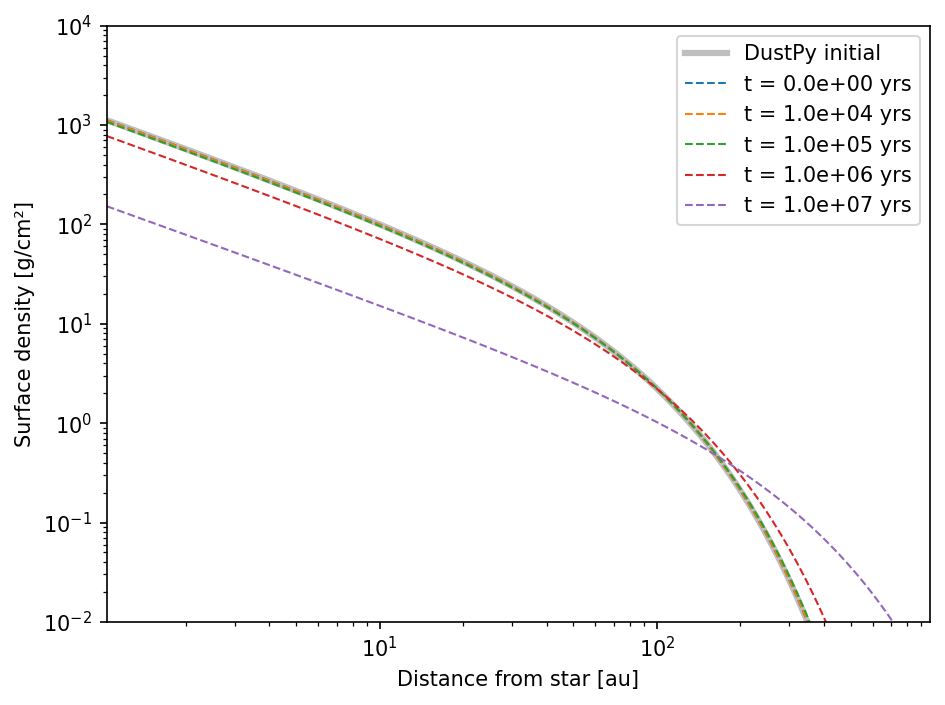

In [5]:
r_au = to_numpy(sim.grid.r) / c.au
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.loglog(r_au, to_numpy(sim.gas.Sigma), c="black", lw=3, alpha=0.25, label="DustPy initial")
ax.loglog(r_au, LBP74_analytical(sim.grid.r, sim.ini.gas.SigmaRc, sim.gas.nu, sim.ini.gas.Mdisk, 0), "--", lw=1, c="C0", label="t = 0.0e+00 yrs")
for i in range(1, len(snapshots)):
    cstr = "C" + str(i)
    ax.loglog(r_au, LBP74_analytical(sim.grid.r, sim.ini.gas.SigmaRc, sim.gas.nu, sim.ini.gas.Mdisk, snapshots[i]), "--", lw=1, c=cstr, label="t = {:3.1e} yrs".format(snapshots[i]/c.year))
ax.legend()
ax.set_xlim(r_au[0], r_au[-1])
ax.set_ylim(1.e-2, 1.e4)
ax.set_xlabel("Distance from star [au]")
ax.set_ylabel("Surface density [g/cm²]")
fig.tight_layout()
plt.show()

## Setting up DustPy

We now set up a `DustPy` simulation to compare the gas evolution to the analytical solutions.

### Turning off Dust Evolution

Since we're not interested in the dust evolution and since this is the computationally most expensive part of `DustPy`, we simply turn it off. We do this by removing the integration instruction and unsetting all updater that are not needed.

In [6]:
sim.dust.S.coag[...] = 0.
sim.dust.S.coag.updater = None
sim.dust.S.ext[...] = 0.
sim.dust.S.ext.updater = None
sim.dust.S.hyd[...] = 0.
sim.dust.S.hyd.updater = None
sim.dust.S.tot[...] = 0.
sim.dust.S.tot.updater = None
sim.dust.S.updater = None
sim.update()

In [7]:
sim.integrator.instructions

[Instruction (Dust: implicit 1st-order direct solver),
 Instruction (Gas: implicit 1st-order direct solver)]

In [8]:
del(sim.integrator.instructions[0])

In [9]:
sim.integrator.instructions

[Instruction (Gas: implicit 1st-order direct solver)]

### Modifying Integration Variable

We set the desired snapshots, that we already defined above.

In [10]:
sim.t.snapshots = snapshots

### Setting Writer Options

We also change the name of the output directory and allow `DustPy` to overwrite existing data files.

In [11]:
sim.writer.datadir = "test_gas_evolution"
sim.writer.overwrite = True

We can now run the simulation.

In [12]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy-GPU): https://astroboylrx.github.io/dustpy-gpu/
Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026; https://ui.adsabs.harvard.edu/abs/2026arXiv260614704L) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[47] =  5.18e-06 g    with
            m[54] =  5.18e-05 g
    - Erosion:
        max. rel. error:  1.78e-15
        for 

Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0001.hdf5


Writing dump file test_gas_evolution/frame.dmp
Writing file test_gas_evolution/data0002.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0003.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0004.hdf5


Writing dump file test_gas_evolution/frame.dmp
Execution time: 0:00:03


### Reading and Plotting Data

We now read the data and compare it to the analytical solutions.

In [13]:
r = sim.writer.read.sequence("grid.r") / c.au
Sigma = sim.writer.read.sequence("gas.Sigma")
nu = sim.writer.read.sequence("gas.nu")
t = sim.writer.read.sequence("t") / c.year

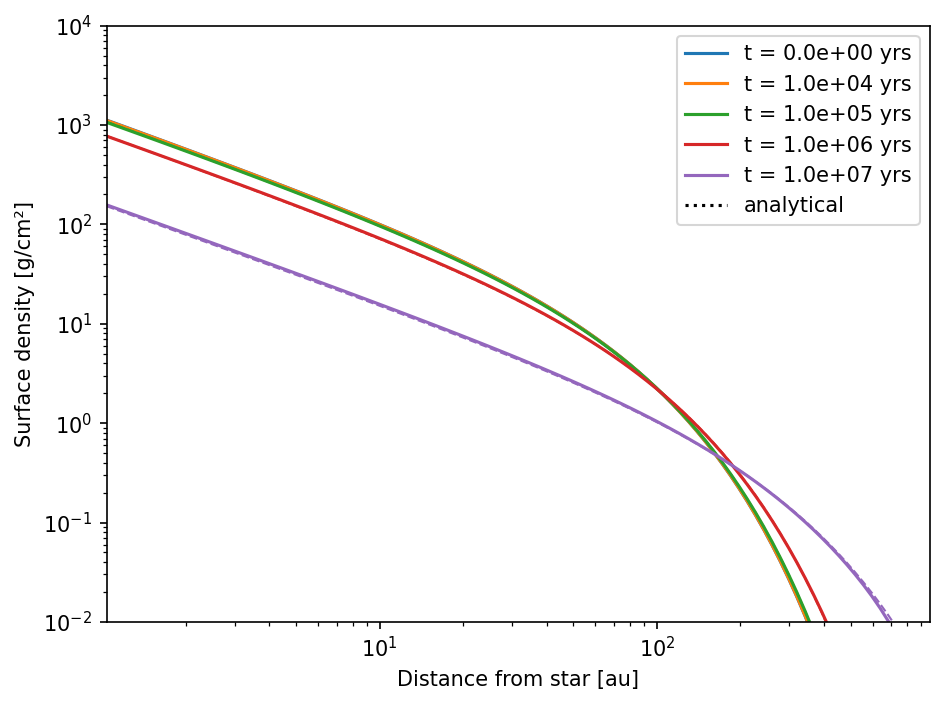

In [14]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.loglog(r[0], Sigma[0], c="C0", label="t = 0.0e+00 yrs")
for i in range(1, len(sim.t.snapshots)):
    cstr = "C"+str(i)
    ax.loglog(r[i], LBP74_analytical(r[i]*c.au, sim.ini.gas.SigmaRc, nu[0], sim.ini.gas.Mdisk, t[i]*c.year), "--", lw=1, c=cstr)
    ax.loglog(r[i], Sigma[i], c=cstr, label="t = {:3.1e} yrs".format(t[i]))
ax.plot(0., 0., ":", c="black", label="analytical")
ax.legend()
ax.set_xlim(r[0, 0], r[0, -1])
ax.set_ylim(1.e-2, 1.e4)
ax.set_xlabel("Distance from star [au]")
ax.set_ylabel("Surface density [g/cm²]")
fig.tight_layout()
plt.show()

As you can see, the time evolution of the gas disk (in the default model) is in good agreement with the analytical solutions.

## Modifying the Power Law Index

We now run the same test again, but we change the initial power law index of the gas surface density profile from $-1.0$ to $-1.5$.

In [15]:
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend
sim.ini.gas.SigmaExp = -1.5

In [16]:
sim.initialize()

In [17]:
sim.dust.S.coag[...] = 0.
sim.dust.S.coag.updater = None
sim.dust.S.ext[...] = 0.
sim.dust.S.ext.updater = None
sim.dust.S.hyd[...] = 0.
sim.dust.S.hyd.updater = None
sim.dust.S.tot[...] = 0.
sim.dust.S.tot.updater = None
sim.dust.S.updater = None
sim.update()

In [18]:
del(sim.integrator.instructions[0])

In [19]:
sim.t.snapshots = snapshots

In [20]:
sim.writer.datadir = "test_gas_evolution"
sim.writer.overwrite = True

In [21]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy-GPU): https://astroboylrx.github.io/dustpy-gpu/
Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026; https://ui.adsabs.harvard.edu/abs/2026arXiv260614704L) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[47] =  5.18e-06 g    with
            m[54] =  5.18e-05 g
    - Erosion:
        max. rel. error:  1.78e-15
        for 

Writing dump file test_gas_evolution/frame.dmp
Writing file test_gas_evolution/data0001.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0002.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0003.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0004.hdf5


Writing dump file test_gas_evolution/frame.dmp
Execution time: 0:00:04


In [22]:
r = sim.writer.read.sequence("grid.r") / c.au
Sigma = sim.writer.read.sequence("gas.Sigma")
nu = sim.writer.read.sequence("gas.nu")
t = sim.writer.read.sequence("t") / c.year

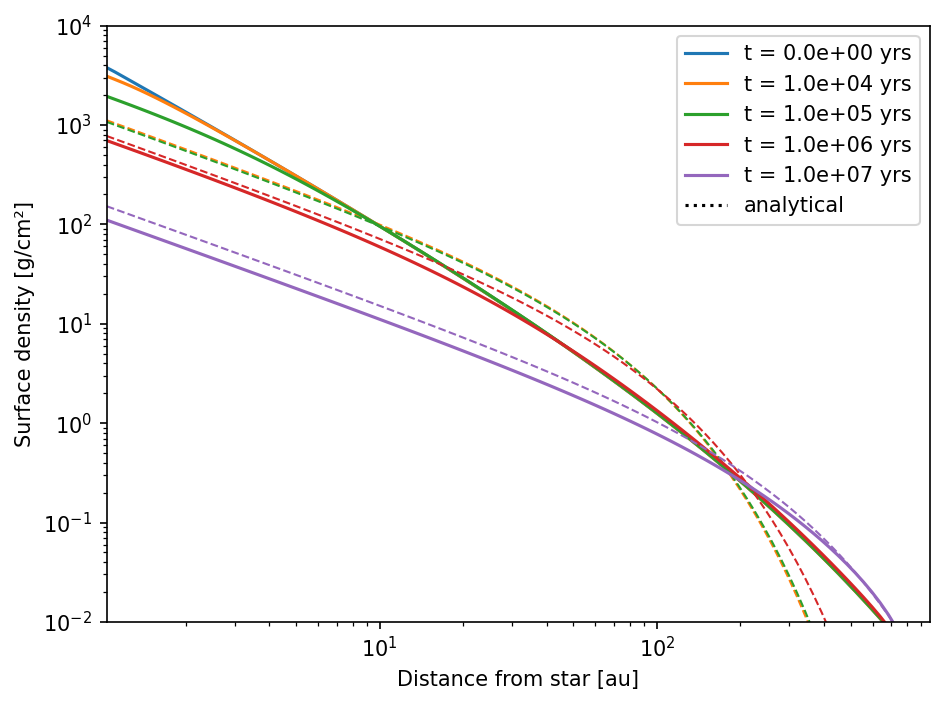

In [23]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.loglog(r[0], Sigma[0], c="C0", label="t = 0.0e+00 yrs")
for i in range(1, len(sim.t.snapshots)):
    cstr = "C"+str(i)
    ax.loglog(r[i], LBP74_analytical(r[i]*c.au, sim.ini.gas.SigmaRc, nu[0], sim.ini.gas.Mdisk, t[i]*c.year), "--", lw=1, c=cstr)
    ax.loglog(r[i], Sigma[i], c=cstr, label="t = {:3.1e} yrs".format(t[i]))
ax.plot(0., 0., ":", c="black", label="analytical")
ax.legend()
ax.set_xlim(r[0, 0], r[0, -1])
ax.set_ylim(1.e-2, 1.e4)
ax.set_xlabel("Distance from star [au]")
ax.set_ylabel("Surface density [g/cm²]")
fig.tight_layout()
plt.show()

The final snapshot looks fine, the previous ones, however, are quite a bit off. Even the initial surface density does not match the analytic solution.  
What went wrong?

The problem is that the initial surface density is not in steady state and therefore not a self-similar solution.  
In steady state the mass flux is constant

$$\Large \frac{\partial}{\partial r} \left( 3\pi\Sigma_\mathrm{g}\nu \right) = \text{const.}$$

Or in other words

$$\Large \Sigma_\mathrm{g}\nu \propto r^p r^\gamma = r^0 \\ \Rightarrow p+\gamma = 0$$

We've change $\large p$ from $-1$ to $-1.5$, but we have not changed $\large \gamma$, which is still $1$ from the default setup as described above. Therefore, in our initial conditions we have

$$\Large p+\gamma=-0.5 \neq 0$$.

Over time the system finds a steady state. Since the temperature profile and the $\large \alpha$-viscosity parameter are both fix in the default model, the only way for the system to get into steady state is by changing the slope of the gas surface density. This is what happened here: the surface density profile went from $-1.5$ initially to $-1$ after $10\,$Myrs.

To fix this problem we need to change the viscosity of the setup. We can do this by either changing the temperature profile, or by changing the $\large \alpha$-profile. We are changing $\large \alpha$ here

$$\Large \alpha \left( r \right) \propto r^\frac{1}{2}$$

which leads to $\large \gamma = 1.5$.

In [24]:
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend
sim.ini.gas.SigmaExp = -1.5
sim.initialize()

In [25]:
sim.gas.alpha[:] = sim.ini.gas.alpha * (sim.grid.r[:]/sim.ini.gas.SigmaRc)**0.5

In [26]:
sim.dust.S.coag[...] = 0.
sim.dust.S.coag.updater = None
sim.dust.S.ext[...] = 0.
sim.dust.S.ext.updater = None
sim.dust.S.hyd[...] = 0.
sim.dust.S.hyd.updater = None
sim.dust.S.tot[...] = 0.
sim.dust.S.tot.updater = None
sim.dust.S.updater = None
sim.update()

In [27]:
del(sim.integrator.instructions[0])

In [28]:
sim.t.snapshots = snapshots

In [29]:
sim.writer.datadir = "test_gas_evolution"
sim.writer.overwrite = True

In [30]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy-GPU): https://astroboylrx.github.io/dustpy-gpu/
Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026; https://ui.adsabs.harvard.edu/abs/2026arXiv260614704L) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[47] =  5.18e-06 g    with
            m[54] =  5.18e-05 g
    - Erosion:
        max. rel. error:  1.78e-15
        for 

Writing dump file test_gas_evolution/frame.dmp
Writing file test_gas_evolution/data0001.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0002.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0003.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0004.hdf5


Writing dump file test_gas_evolution/frame.dmp
Execution time: 0:00:06


In [31]:
r = sim.writer.read.sequence("grid.r") / c.au
Sigma = sim.writer.read.sequence("gas.Sigma")
nu = sim.writer.read.sequence("gas.nu")
t = sim.writer.read.sequence("t") / c.year

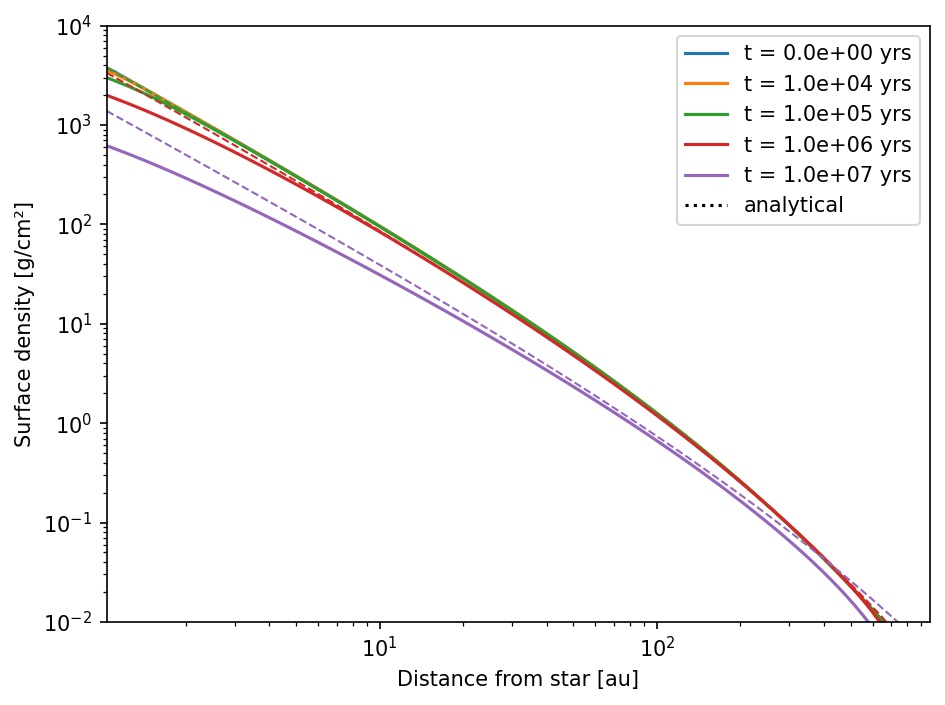

In [32]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.loglog(r[0], Sigma[0], c="C0", label="t = 0.0e+00 yrs")
for i in range(1, len(sim.t.snapshots)):
    cstr = "C"+str(i)
    ax.loglog(r[i], LBP74_analytical(r[i]*c.au, sim.ini.gas.SigmaRc, nu[0], sim.ini.gas.Mdisk, t[i]*c.year), "--", lw=1, c=cstr)
    ax.loglog(r[i], Sigma[i], c=cstr, label="t = {:3.1e} yrs".format(t[i]))
ax.plot(0., 0., ":", c="black", label="analytical")
ax.legend()
ax.set_xlim(r[0, 0], r[0, -1])
ax.set_ylim(1.e-2, 1.e4)
ax.set_xlabel("Distance from star [au]")
ax.set_ylabel("Surface density [g/cm²]")
fig.tight_layout()
plt.show()

This is closer to the analytical solutions. However, there are stil deviations at the inner boundary of the grid.

The reason for this is the inner boundary condition.  
By default this is set to constant gradient

$$\Large \frac{1}{r}\frac{\partial}{\partial r} \left( r\Sigma_\mathrm{g} \right) = \text{const.}$$

This can be set exactly within a linear system, such as the one that is solved for gas evolution. A surface density profile of $-1$ as is set for the default model has automatically a constant gradient at the inner boundary. But a surface density profile of $-1.5$ does not. Here we need to change the inner boundary condition to constant power law.

In [33]:
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend
sim.ini.gas.SigmaExp = -1.5
sim.initialize()

In [34]:
sim.gas.alpha[:] = sim.ini.gas.alpha * (sim.grid.r[:]/sim.ini.gas.SigmaRc)**0.5

In [35]:
sim.dust.S.coag[...] = 0.
sim.dust.S.coag.updater = None
sim.dust.S.ext[...] = 0.
sim.dust.S.ext.updater = None
sim.dust.S.hyd[...] = 0.
sim.dust.S.hyd.updater = None
sim.dust.S.tot[...] = 0.
sim.dust.S.tot.updater = None
sim.dust.S.updater = None
sim.update()

In [36]:
del(sim.integrator.instructions[0])

In [37]:
sim.gas.boundary.inner.setcondition("const_pow")

In [38]:
sim.t.snapshots = snapshots

In [39]:
sim.writer.datadir = "test_gas_evolution"
sim.writer.overwrite = True

In [40]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy-GPU): https://astroboylrx.github.io/dustpy-gpu/
Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026; https://ui.adsabs.harvard.edu/abs/2026arXiv260614704L) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[47] =  5.18e-06 g    with
            m[54] =  5.18e-05 g
    - Erosion:
        max. rel. error:  1.78e-15
        for 

Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0001.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0002.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0003.hdf5


Writing dump file test_gas_evolution/frame.dmp


Writing file test_gas_evolution/data0004.hdf5


Writing dump file test_gas_evolution/frame.dmp
Execution time: 0:00:06


In [41]:
r = sim.writer.read.sequence("grid.r") / c.au
Sigma = sim.writer.read.sequence("gas.Sigma")
nu = sim.writer.read.sequence("gas.nu")
t = sim.writer.read.sequence("t") / c.year

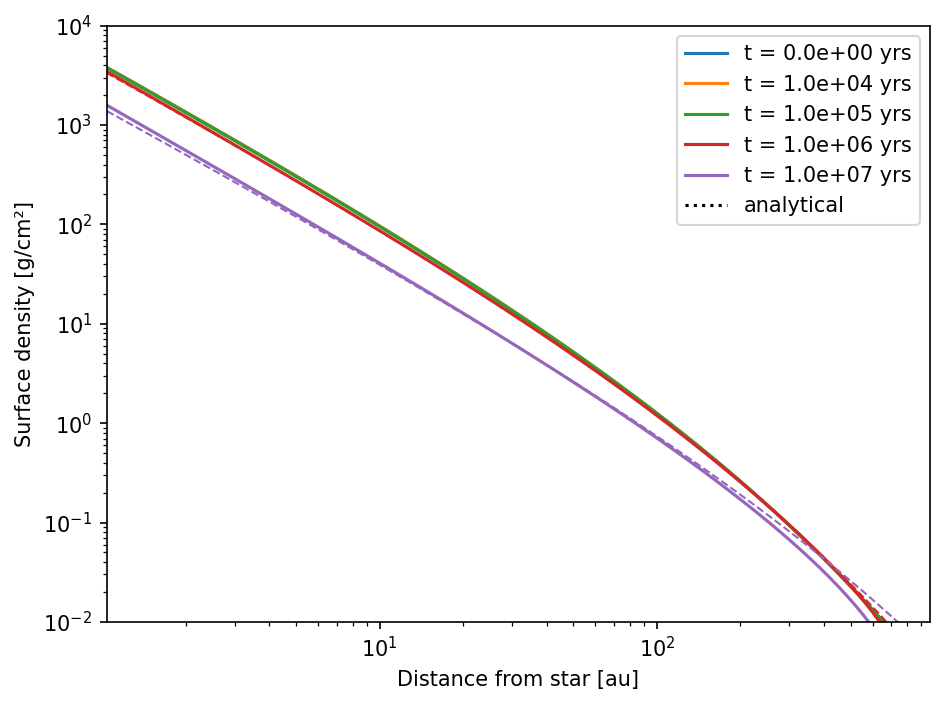

In [42]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
ax.loglog(r[0], Sigma[0], c="C0", label="t = 0.0e+00 yrs")
for i in range(1, len(sim.t.snapshots)):
    cstr = "C"+str(i)
    ax.loglog(r[i], LBP74_analytical(r[i]*c.au, sim.ini.gas.SigmaRc, nu[0], sim.ini.gas.Mdisk, t[i]*c.year), "--", lw=1, c=cstr)
    ax.loglog(r[i], Sigma[i], c=cstr, label="t = {:3.1e} yrs".format(t[i]))
ax.plot(0., 0., ":", c="black", label="analytical")
ax.legend()
ax.set_xlim(r[0, 0], r[0, -1])
ax.set_ylim(1.e-2, 1.e4)
ax.set_xlabel("Distance from star [au]")
ax.set_ylabel("Surface density [g/cm²]")
fig.tight_layout()
plt.show()

This is not perfect, but as good as it can get. The deviation at the outer boundary is due to the fact that the outer boundary conditions is setting the gas to its floor value to prevent inflow.

In general: Always test your models against analytical solutions, if possible and decide then if the errors are acceptable for you.

### Why is the inner boundary condition not constant power law by default?

The reason for that is that a constant power law is not necessarily possible within a linear system. A power of $-1.5$ for example is not.

`DustPy` is "*cheating*" here a bit. A boundary condition of `const_pow` is behind the scenes actually a boundary condition of `val`, where the value is calculated from the current surface density. This is close enough to the actual value in most cases. After the integration the boundary condition is then strictly enforced, by setting the correct power with the new values of the surface density.

Since the default model uses a power of $-1$ and since this can be done exactly with the `const_grad` boundary condition, we prefer it over the `const_pow` condition in the default setup.